  # Examen 3V2


Nombre: **<font color = 'cyan'> **Francisco Javier Nava Valecia** </font>**

### Física Computacional 2026-2

Resuelva los siguientes ejercicios.

Considere N=(Primeros dos dígitos de su número de cuenta) $\times$ (Últimos dos dígitos de su número de cuenta), para comprobar el funcionamiento de sus funciones

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
import random

Numero_cuenta = str(316013936)
p2 = Numero_cuenta[0:2]
u2 = Numero_cuenta[-2::]
N = int(p2) * int(u2)
print(N)

1116


1. Genere una función que en el plano $xy$ se tenga una malla numérica de $N\times N$ con $x \in [0,1]$ y $y\in [0,1]$. En cada punto de la malla ponga un número aleatorio entre 0 y 1 si el punto pertenece al cuadrado y no pertence a un cículo con centro en cada uno de los vertices del cuadrado con radio 0.25. En el resto de los puntos ponga el número 0. Haga el dibujo de su función con la función imshow()

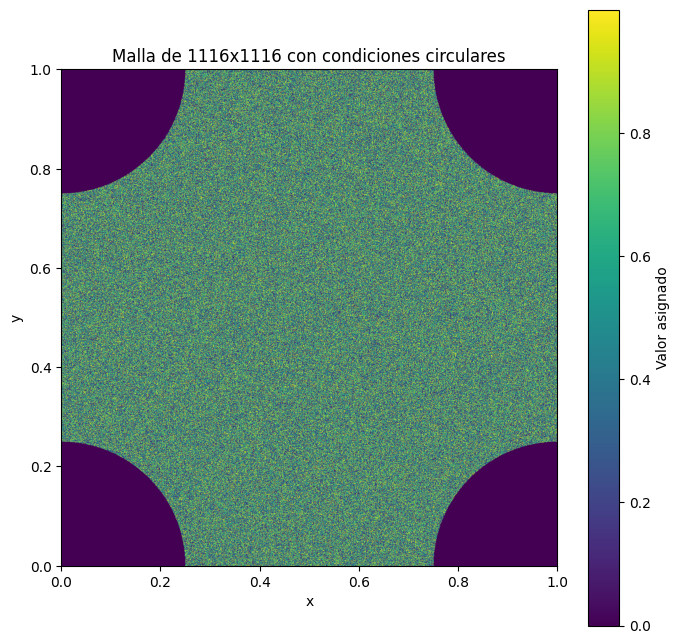

In [5]:
def generate_circular_grid(N):
    #Creamos la malla de NxN puntos
    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)
    X, Y = np.meshgrid(x,y)
    
    #Inicializamos la malla con zeros
    grid = np.zeros((N,N))

    #Definimos los centros de los circulos que estaran en las esquinas
    centros = [(0,0),(0,1),(1,0),(1,1)]
    radio = 0.25
    
    #Iteramos cada punto de la malla
    for i in range(N):
        for j in range(N):
            current_x = X[i,j]
            current_y = Y[i,j]

            #checamos que el punto este dentro del cuadrado [0,1]x[0,1]
            dentro_cuadrado = (0 <= current_x <= 1) and (0 <= current_y <= 1) #solo True o False

            #Checar si el punto no esta en ninguno de los circulos externos
            outside_circles = True
            for cx, cy in centros:
                distance = np.sqrt((current_x - cx)**2 + (current_y - cy)**2)
                if distance < radio:
                    outside_circles = False
            
            #Si ambas condiciones se cumplen asignaremos un punto aleatorio
            if dentro_cuadrado and outside_circles: #True/True o False/True
                grid[i,j] = random.uniform(0,1)
    return grid

#Generamos el grid usando el calculo de N
malla = generate_circular_grid(N)

#Mostramos la malla usando imshow dado que lo considermaos una imagen
plt.figure(figsize=(8, 8))
plt.imshow(malla, origin='lower', cmap='viridis', extent=[0, 1, 0, 1])
plt.title(f'Malla de {N}x{N} con condiciones circulares')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Valor asignado')
plt.show()

2. Genere una función que haga una matriz de $N\times N$ con la siguientes características:
   - En la diagonal principal debe tener el valor $1/N$
   - En la diagonal superior a la principal debe tener el valor $1/N^2$
   - En la diagonal inferior a la principal debe tener el valor $1/N^3$

In [7]:
def gen_special(N):
    #Generamos la matriz a trabajar
    matrix = np.zeros((N,N)) #Vacia de momento

    #Diagonal principal
    np.fill_diagonal(matrix,1/N)

    #Matriz superior 
    if N > 1:
        np.fill_diagonal(matrix[:,1:], 1/(N**2)) #llenamos la diagonal de la columna 1 en adelante
    
    if N > 1:
        np.fill_diagonal(matrix[1:,:], (1/(N**3)))
    return matrix

#Generamos la matriz 
spec_matrix = gen_special(N)
display(spec_matrix[:5,:5])

array([[8.96057348e-04, 8.02918770e-07, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [7.19461264e-10, 8.96057348e-04, 8.02918770e-07, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 7.19461264e-10, 8.96057348e-04, 8.02918770e-07,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 7.19461264e-10, 8.96057348e-04,
        8.02918770e-07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.19461264e-10,
        8.96057348e-04]])

3. Genere una función que reciba una matriz y que a la salida proporcione la matriz transpuesta, la inversa de una matriz y el cuadrado de dicha matriz ($A^2 = A A$)

In [11]:
def Matrix_op(matrix):
    #Transpuesta
    transpose = matrix.T

    #inversa (para ello checamos que sea cuadrada e invertible)
    if matrix.shape[0] != matrix.shape[1]:
        print("Matriz no cuadrada")
        inverse = None
    else:
        try:
            inverse = np.linalg.inv(matrix)
        except np.linalg.LinAlgError:
            print("No se pudo invertir, la matriz es singular")
            inverse = None
    
    #Cuadrado
    square = matrix @ matrix
    return transpose,inverse,square

#----TEST---
#nota: Si N es largo , el calculo de la inversa puede tomar demasiado tempo
#Para la demostración usaremos un amatrix pequeña o un subconjunto de nuestra matriz original

#Creamos una matriz pequeña para demostración
matrix = np.array([[1,2],[3,4]])

transposed, inversed, squared = Matrix_op(matrix)

print("\n--- Demonstrating with a small 2x2 matrix ---")
print("Original Matrix:")
display(matrix)
print("\nTransposed Matrix:")
display(transposed)
print("\nInverse Matrix:")
display(inversed)
print("\nSquared Matrix (A @ A):")
display(squared)



--- Demonstrating with a small 2x2 matrix ---
Original Matrix:


array([[1, 2],
       [3, 4]])


Transposed Matrix:


array([[1, 3],
       [2, 4]])


Inverse Matrix:


array([[-2. ,  1. ],
       [ 1.5, -0.5]])


Squared Matrix (A @ A):


array([[ 7, 10],
       [15, 22]])

4. Genere la misma función que se solicita en el problema dos, pero utilice matrices espacidas debido a la gran cantidad de ceros.

In [13]:
def Matrix_spare(N):
    #Diagonal principal
    d0 = (1/N) * np.ones(N)

    #Diagonal superior 
    d1 = (1/N**2) * np.ones(N-1)

    # Diagonal inferior
    d_1 = (1/N**3) * np.ones(N-1)

    #Cotrución de la matriz spare
    A = diags([d_1,d0,d1],offsets= [-1,0,1],
              format='csr')
    return A

A = Matrix_spare(N)
display(A[:5,:5])
print(A)



<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (5, 5)>

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3346 stored elements and shape (1116, 1116)>
  Coords	Values
  (0, 0)	0.0008960573476702509
  (0, 1)	8.029187703138448e-07
  (1, 0)	7.194612637220833e-10
  (1, 1)	0.0008960573476702509
  (1, 2)	8.029187703138448e-07
  (2, 1)	7.194612637220833e-10
  (2, 2)	0.0008960573476702509
  (2, 3)	8.029187703138448e-07
  (3, 2)	7.194612637220833e-10
  (3, 3)	0.0008960573476702509
  (3, 4)	8.029187703138448e-07
  (4, 3)	7.194612637220833e-10
  (4, 4)	0.0008960573476702509
  (4, 5)	8.029187703138448e-07
  (5, 4)	7.194612637220833e-10
  (5, 5)	0.0008960573476702509
  (5, 6)	8.029187703138448e-07
  (6, 5)	7.194612637220833e-10
  (6, 6)	0.0008960573476702509
  (6, 7)	8.029187703138448e-07
  (7, 6)	7.194612637220833e-10
  (7, 7)	0.0008960573476702509
  (7, 8)	8.029187703138448e-07
  (8, 7)	7.194612637220833e-10
  (8, 8)	0.0008960573476702509
  :	:
  (1107, 1107)	0.0008960573476702509
  (1107, 1108)	8.029187703138448e-07
  (1108, 1107)	7.19461